DATA LOADING

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import LeaveOneGroupOut
from captum.attr import IntegratedGradients, DeepLift, FeatureAblation
import matplotlib.pyplot as plt


print("Loading preprocessed data...")
data = np.load('preprocessed_data.npz')
X_cnn_input = data['X_cnn']
y_flat_bin = data['y_bin']

num_subjects = X_cnn_input.shape[0] // 40
groups = np.repeat(np.arange(num_subjects), 40)
logo = LeaveOneGroupOut()
print(f"Loaded {num_subjects} subjects. Shape: {X_cnn_input.shape}")

d:\miniconda\envs\final_xai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading preprocessed data...
Loaded 31 subjects. Shape: (1240, 32, 7680)


MODEL ARCHI

In [2]:
class ZhaoCNN(nn.Module):
    def __init__(self):
        super(ZhaoCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=125)
        self.pool = nn.MaxPool1d(kernel_size=4)
        self.dropout = nn.Dropout(0.3) 
        self.fc1 = nn.Linear(64 * 1889, 128)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.sigmoid(self.fc2(x))
        return x

TRAINING

In [3]:
cnn_results = []

for train_idx, test_idx in logo.split(X_cnn_input, y_flat_bin, groups):
    subject_id = groups[test_idx][0] + 1
    
    X_train_cpu = torch.tensor(X_cnn_input[train_idx], dtype=torch.float32)
    y_train_cpu = torch.tensor(y_flat_bin[train_idx], dtype=torch.float32).unsqueeze(1)
    train_loader = DataLoader(TensorDataset(X_train_cpu, y_train_cpu), batch_size=64, shuffle=True)
    
    model_zhao = ZhaoCNN().cuda()
    optimizer_zhao = optim.Adam(model_zhao.parameters(), lr=0.0005)
    criterion = nn.BCELoss()
    
    model_zhao.train()
    for epoch in range(15):
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.cuda(), batch_y.cuda()
            
            optimizer_zhao.zero_grad()
            outputs = model_zhao(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer_zhao.step()
            
    # Evaluation
    model_zhao.eval()
    with torch.no_grad():
        X_test = torch.tensor(X_cnn_input[test_idx], dtype=torch.float32).cuda()
        y_test = torch.tensor(y_flat_bin[test_idx], dtype=torch.float32).unsqueeze(1).cuda()
        preds = (model_zhao(X_test) > 0.5).float()
        acc = (preds == y_test).float().mean().item()
        
    print(f"Subject {subject_id} Accuracy: {acc*100:.2f}%")
    cnn_results.append({'Subject': subject_id, 'Accuracy': acc})

cnn_avg_acc = np.mean([r['Accuracy'] for r in cnn_results])
print(f"\nZhaoCNN Subject-Independent Mean Accuracy: {cnn_avg_acc*100:.2f}%")

Subject 1 Accuracy: 15.00%
Subject 2 Accuracy: 85.00%
Subject 3 Accuracy: 47.50%
Subject 4 Accuracy: 72.50%
Subject 5 Accuracy: 57.50%
Subject 6 Accuracy: 75.00%
Subject 7 Accuracy: 80.00%
Subject 8 Accuracy: 87.50%
Subject 9 Accuracy: 77.50%
Subject 10 Accuracy: 62.50%
Subject 11 Accuracy: 95.00%
Subject 12 Accuracy: 95.00%
Subject 13 Accuracy: 80.00%
Subject 14 Accuracy: 70.00%
Subject 15 Accuracy: 85.00%
Subject 16 Accuracy: 77.50%
Subject 17 Accuracy: 82.50%
Subject 18 Accuracy: 12.50%
Subject 19 Accuracy: 85.00%
Subject 20 Accuracy: 95.00%
Subject 21 Accuracy: 85.00%
Subject 22 Accuracy: 60.00%
Subject 23 Accuracy: 90.00%
Subject 24 Accuracy: 87.50%
Subject 25 Accuracy: 75.00%
Subject 26 Accuracy: 15.00%
Subject 27 Accuracy: 25.00%
Subject 28 Accuracy: 87.50%
Subject 29 Accuracy: 75.00%
Subject 30 Accuracy: 60.00%
Subject 31 Accuracy: 75.00%

ZhaoCNN Subject-Independent Mean Accuracy: 70.08%


XAI (4 Techniques)

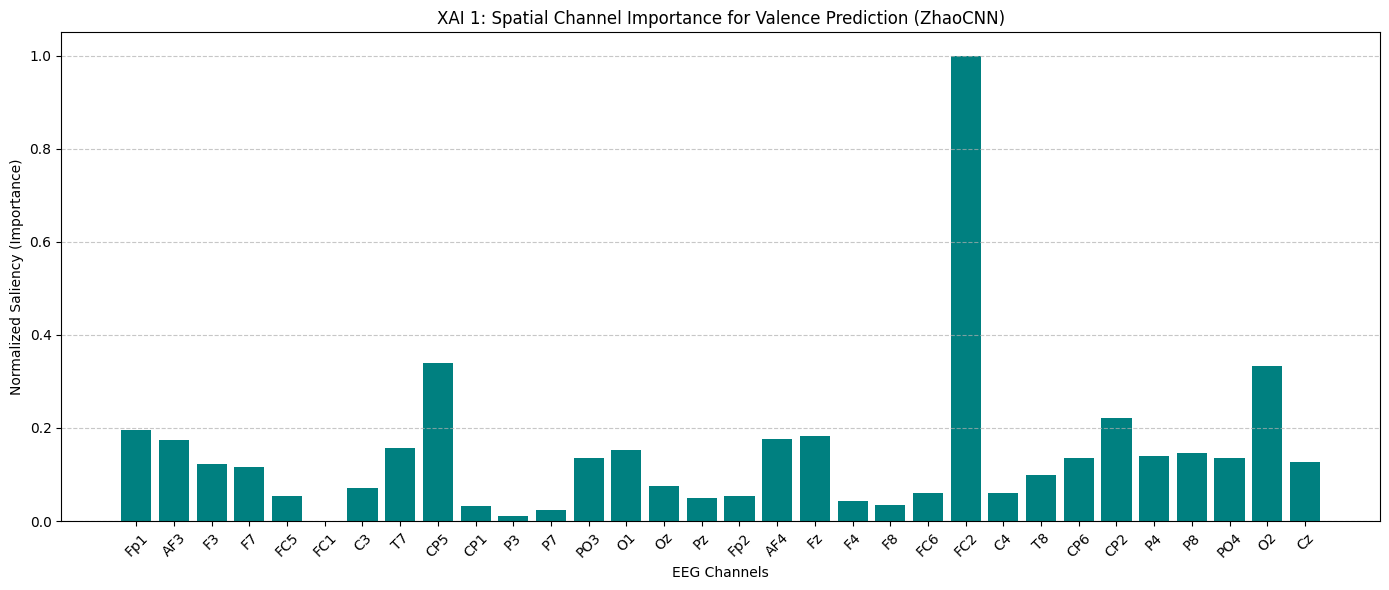

In [5]:
# Saliency
def get_eeg_channel_importance(model, x):
    model.eval()
    x.requires_grad_()
    output = model(x)
    output.backward(torch.ones_like(output))
    gradients = x.grad.abs()
    channel_importance = gradients.mean(dim=(0, 2))
    channel_importance = (channel_importance - channel_importance.min()) / (channel_importance.max() - channel_importance.min())
    return channel_importance.cpu().detach().numpy()

X_test_xai = torch.tensor(X_cnn_input[test_idx], dtype=torch.float32).cuda()
original_activation = model_zhao.sigmoid
model_zhao.sigmoid = nn.Identity()
importances = get_eeg_channel_importance(model_zhao, X_test_xai)
model_zhao.sigmoid = original_activation

deap_channels = ['Fp1', 'AF3', 'F3', 'F7', 'FC5', 'FC1', 'C3', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO3', 'O1', 'Oz', 'Pz', 'Fp2', 'AF4', 'Fz', 'F4', 'F8', 'FC6', 'FC2', 'C4', 'T8', 'CP6', 'CP2', 'P4', 'P8', 'PO4', 'O2', 'Cz']
plt.figure(figsize=(14, 6))
plt.bar(deap_channels[:32], importances, color='teal')
plt.title("XAI 1: Spatial Channel Importance for Valence Prediction (ZhaoCNN)")
plt.ylabel("Normalized Saliency (Importance)")
plt.xlabel("EEG Channels")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [6]:
sample_input = torch.tensor(X_cnn_input[:5], dtype=torch.float32).cuda()
sample_input.requires_grad_()


tensor([[[ 4.0521e+00,  2.8912e+00, -1.7796e+00,  ..., -2.8265e+00,
          -4.4772e+00, -3.6769e+00],
         [ 3.0533e+00,  4.1285e+00, -1.6248e-02,  ..., -2.9870e+00,
          -6.2878e+00, -4.4743e+00],
         [ 1.1861e+00,  4.6164e+00,  8.0340e-01,  ..., -2.6371e+00,
          -7.4065e+00, -6.7559e+00],
         ...,
         [ 2.7454e+00,  3.1380e+00,  4.5846e+00,  ...,  6.6889e+00,
           6.9123e+00,  5.6690e+00],
         [ 2.8141e+00,  3.1925e+00,  5.3309e+00,  ...,  2.6402e+00,
           6.5746e+00,  7.2085e+00],
         [ 3.6660e+00,  4.6715e+00,  5.0073e+00,  ...,  2.2396e+00,
           3.1826e+00,  4.7081e+00]],

        [[-4.5237e+00, -1.2017e+01, -1.2776e+01,  ...,  6.0222e+00,
           7.5391e+00,  9.3522e+00],
         [-6.3873e-01, -4.6656e+00, -7.2800e+00,  ...,  6.0340e+00,
           9.0687e+00,  8.7402e+00],
         [ 1.4753e+00, -1.7570e+00, -5.0330e+00,  ...,  6.1797e+00,
           6.9337e+00,  6.4809e+00],
         ...,
         [ 2.8278e+00,  3

In [7]:
# Integrated Gradients
ig = IntegratedGradients(model_zhao)
ig_attr = ig.attribute(sample_input, target=0)
print("Integrated Gradients execution done.")

Integrated Gradients execution done.


In [8]:
#DeepLift
dl = DeepLift(model_zhao)
dl_attr = dl.attribute(sample_input, target=0)
print("DeepLift execution done.")

DeepLift execution done.


d:\miniconda\envs\final_xai\lib\site-packages\captum\log\dummy_log.py:54: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)


In [11]:
import torch

num_channels = sample_input.shape[1] 
mask = torch.arange(num_channels).view(1, num_channels, 1).to(sample_input.device)
mask = mask.expand_as(sample_input)

ablator = FeatureAblation(model_zhao)
ablation_attr = ablator.attribute(sample_input, target=0, feature_mask=mask)
print("Grouped Feature Ablation execution done.")

Grouped Feature Ablation execution done.


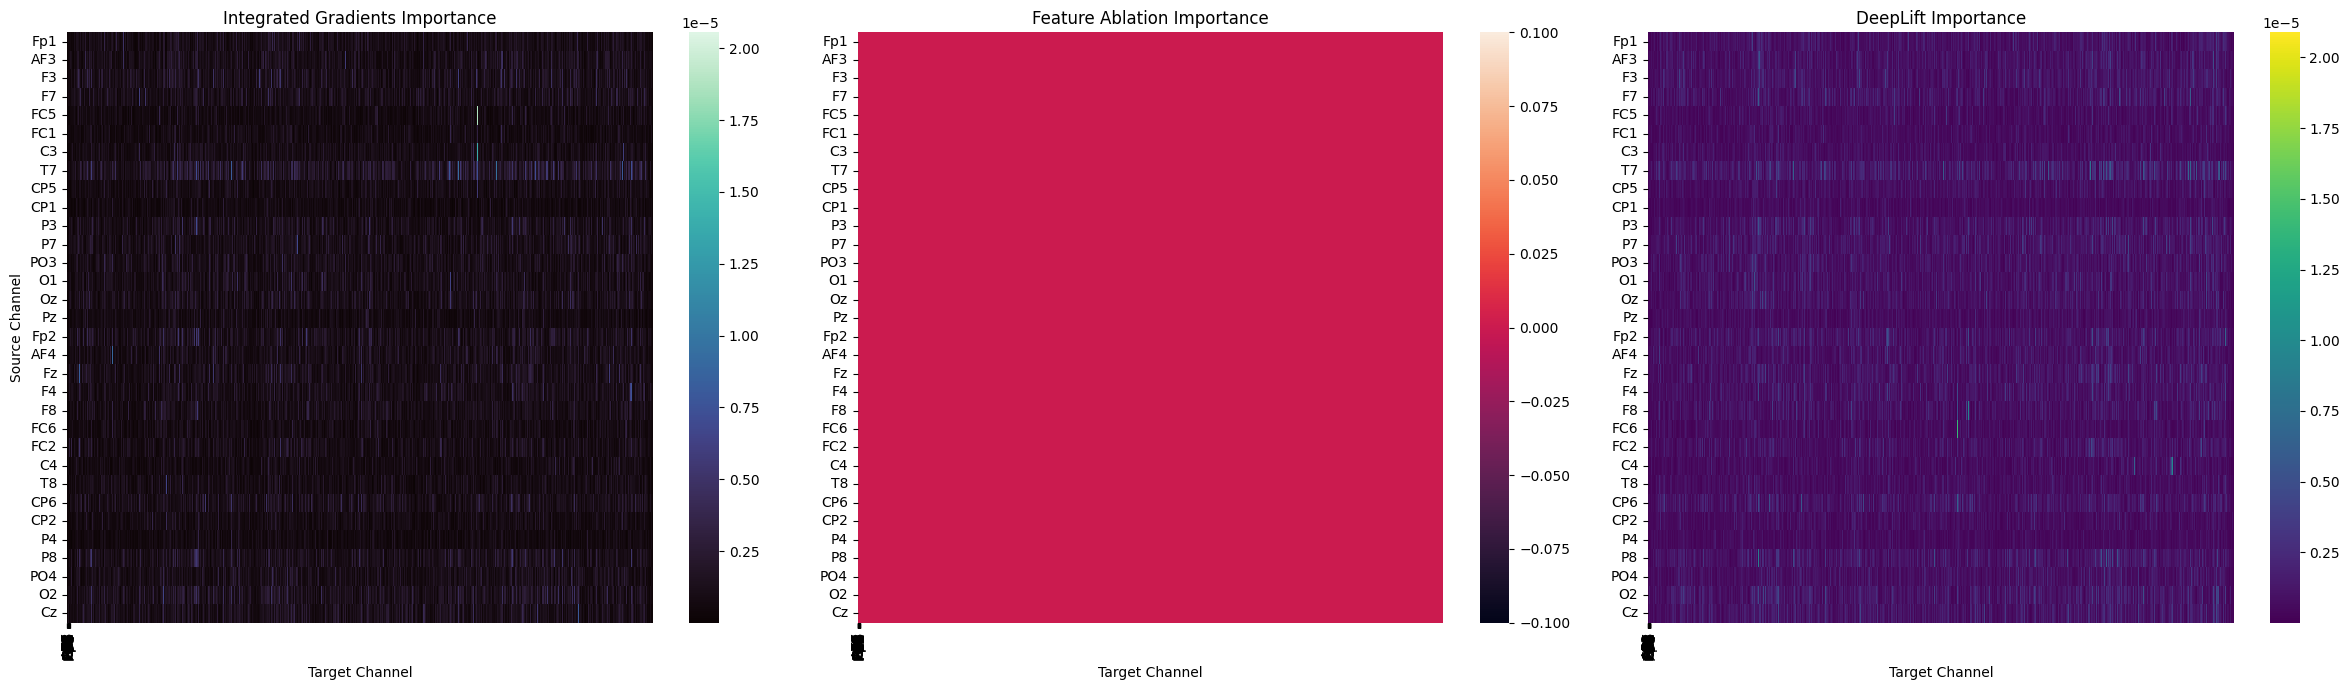

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

def process_attr(attr_tensor):
    return attr_tensor.abs().mean(dim=0).squeeze().cpu().detach().numpy()

ig_matrix = process_attr(ig_attr)
ablation_matrix = process_attr(ablation_attr)
dl_matrix = process_attr(dl_attr) 

# Integrated Gradients
sns.heatmap(ig_matrix, ax=axes[0], cmap='mako', xticklabels=deap_channels[:32], yticklabels=deap_channels[:32])
axes[0].set_title("Integrated Gradients Importance")
axes[0].set_ylabel("Source Channel")
axes[0].set_xlabel("Target Channel") 

# Feature Ablation
sns.heatmap(ablation_matrix, ax=axes[1], cmap='rocket', xticklabels=deap_channels[:32], yticklabels=deap_channels[:32])
axes[1].set_title("Feature Ablation Importance")
axes[1].set_xlabel("Target Channel")

# DeepLift
sns.heatmap(dl_matrix, ax=axes[2], cmap='viridis', xticklabels=deap_channels[:32], yticklabels=deap_channels[:32])
axes[2].set_title("DeepLift Importance") 
axes[2].set_xlabel("Target Channel")

plt.tight_layout()
plt.show()